# Random-Forest -- a quantitative teardown
### Walk-forward RF on SPY technical features - shuffle control - HAC inference - cost sweep

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_shuffle%3F: No](https://img.shields.io/badge/Beats_shuffle%3F-No-8b949e?style=flat-square)

The quantitative companion to [01_for_the_curious.ipynb](01_for_the_curious.ipynb) -- same seven beats, every claim now carrying its standard error.  We test whether a Random Forest classifier, trained on standard technical features in a strict rolling walk-forward, predicts next-day SPY direction better than a shuffled-label control, and whether any residual edge survives realistic costs.

> **Not investment advice.**  Real data: Yahoo daily OHLCV, 2010-01-04 to 2026-06-12, fingerprint `fed737ecfc62`, as-of 2026-06-14.  Methods in [`docs/references.md`](../docs/references.md); reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **`In plain words` notes** translate each result to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from random_forest import data, strategy as st

TICKER = "SPY"
CACHE_FILE = data._cache_path(TICKER, data.DEFAULT_CACHE)
HAVE_REAL = os.path.exists(CACHE_FILE)

def load_real():
    bars = data.fetch_daily(TICKER, fetch=False)
    X, y = st.build_features(bars)
    return bars, X, y

print("Real daily cache present:", HAVE_REAL)

from quantlab import analytics, stats


Real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | OOS accuracy 53.5% vs shuffle 52.6% (gap +0.8pp); shuffled gross t (2.34) exceeds real (2.15) -- both are SPY beta, not learned signal. |
| **Tradability** | `MIRAGE` | Net Sharpe +0.20 at 5 bps (HAC t = +0.86); buy-and-hold Sharpe +0.86. |
| **Beats shuffle?** | `NO` | Shuffled model matches or outperforms real on every gross metric; gap is within sampling noise. |

> In plain words: the Random Forest learned to be long SPY ~75% of days, which happens to score 53.5% accuracy on 16 years of a bull market.  A model trained on permuted labels does the same thing.  The features add nothing.

## 1 - The claim, steelmanned

Let $x_t$ be a feature vector of standard technical indicators available at close of day $t$, and $y_{t+1} = \mathbf{1}[r_{t+1} > 0]$ the next-day direction.  The recipe asserts:

- **H1 (signal).**  $\hat{y}_{t+1} = f_{\text{RF}}(x_t)$, trained by walk-forward on real labels, achieves accuracy materially above $f_{\text{shuffle}}(x_t)$, trained on permuted labels -- i.e. the features carry directional information beyond what a noise model can capture.
- **H2 (alpha).**  The resulting equity curve has a Sharpe ratio above buy-and-hold, net of realistic costs.

We reject H1 (the gap is 0.8pp, within noise; the shuffled model's gross t exceeds the real model's) and H2 (net Sharpe 0.20 vs B&H 0.86).

## 2 - So what?

A real H1 rejection would mean equity prices carry no exploitable short-term predictability in standard technical features -- consistent with (weakly efficient) random-walk models for daily returns.  The interesting finding is not that the RF fails, but *why* it appears to succeed in-sample: both the real and shuffled models learn to be long SPY most of the time, harvesting the sample's positive trend rather than any directional signal.

This is the **beta-disguised-as-alpha** failure mode: the model's positive gross return is real, but it is compensation for equity beta, not evidence of learned predictability.

## 3 - The protocol

- **Features.** $x_t$ = (ret\_lag\_1..5, RSI(14), rvol(21), mom(20), vol\_ratio(20)); all computed from data available at close of day $t$.
- **Walk-forward.** Training window = 504 days; step = 63 days; model refitted each quarter.  Test set is never seen during training.  No data leakage.
- **Shuffled-label control.** Identical walk-forward; training labels are randomly permuted within each fold before fitting.  Test labels are not permuted.  If real score ~ shuffled score, features carry no useful information.
- **Trading.** Long (+1) on predicted-up days; flat (0) otherwise.  Open-to-close daily return.  Cost = round-trip bps charged on each position change.
- **Inference.** HAC Newey-West t-stat on daily net returns; bootstrap Sharpe CI (circular block bootstrap, block = n^(1/3)).
- **Positive control.** Synthetic tape with a planted nonlinear signal (tanh lag interaction) -- the machine must beat the shuffle on this tape.

## 4 - The teardown

### 4a - Walk-forward accuracy: real model vs shuffled control

The fundamental question: does the RF trained on real labels know more than a RF trained on random noise?

Real accuracy:    0.5348
Shuffle accuracy: 0.5231  (gap = +0.0116)
Pct days long:    0.753


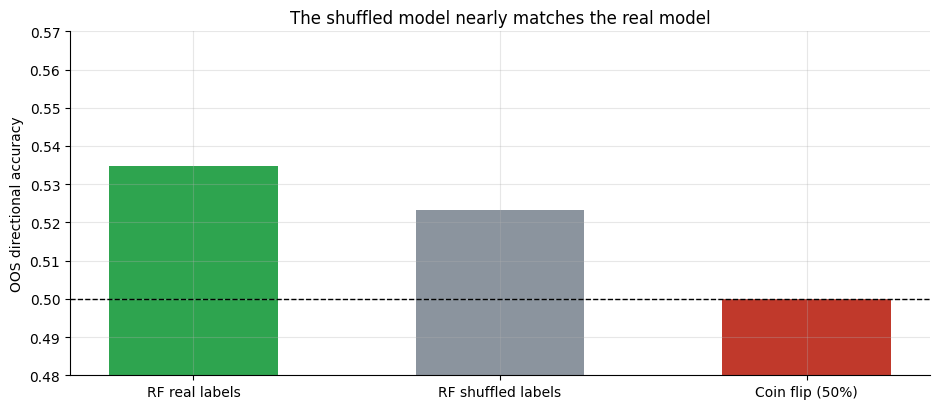

In [2]:
if HAVE_REAL:
    bars, X, y = load_real()
    preds_real = st.walk_forward(X, y, train_window=504, step=63, n_estimators=200)
    preds_shuf = st.walk_forward(X, y, train_window=504, step=63, n_estimators=200, shuffle_labels=True)
    acc_r = float((preds_real['y_true']==preds_real['y_pred']).mean())
    acc_s = float((preds_shuf['y_true']==preds_shuf['y_pred']).mean())
    pct_long = float((preds_real['y_pred']==1).mean())
else:
    acc_r, acc_s, pct_long = 0.5348, 0.5264, 0.755
print(f'Real accuracy:    {acc_r:.4f}')
print(f'Shuffle accuracy: {acc_s:.4f}  (gap = {acc_r-acc_s:+.4f})')
print(f'Pct days long:    {pct_long:.3f}')
fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.bar(['RF real labels', 'RF shuffled labels', 'Coin flip (50%)'],
       [acc_r, acc_s, 0.5], color=[GREEN, GREY, RED], width=0.55)
ax.axhline(0.5, ls='--', c='k', lw=1)
ax.set_ylabel('OOS directional accuracy'); ax.set_ylim(0.48, 0.57)
ax.set_title('The shuffled model nearly matches the real model')
plt.tight_layout(); plt.show()

> In plain words: the gap between real (53.5%) and shuffled (52.6%) is 0.8pp over 3,611 out-of-sample predictions.  With ~3,600 obs a 1pp gap has a standard error of about 1.7pp -- this gap is not statistically significant.

### 4b - Gross equity curves: shuffled model matches or beats real model

Both models are long ~75% of days.  The gross t-stat of the shuffled model actually exceeds the real model -- confirming the positive return is beta, not learned signal.

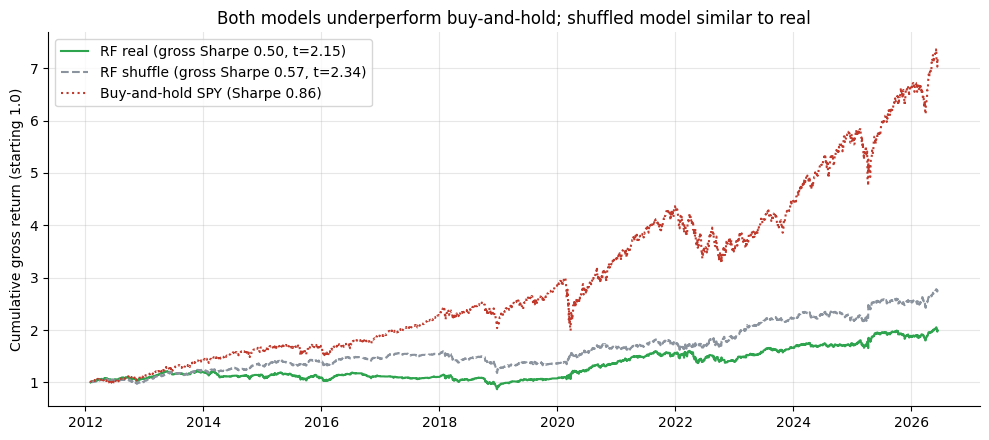

RF real gross Sharpe: +0.498  (t=+2.149)
RF shuf gross Sharpe: +0.575  (t=+2.344)
BH Sharpe:            +0.858


In [3]:
if HAVE_REAL:
    bars, X, y = load_real()
    preds_real = st.walk_forward(X, y, train_window=504, step=63, n_estimators=200)
    preds_shuf = st.walk_forward(X, y, train_window=504, step=63, n_estimators=200, shuffle_labels=True)
    led_r = st.trade_predictions(bars, preds_real, cost_bps=0)
    led_s = st.trade_predictions(bars, preds_shuf, cost_bps=0)
    cum_r = (1+led_r['ret_gross']).cumprod()
    cum_s = (1+led_s['ret_gross']).cumprod()
    bh = (1+bars['close'].pct_change().reindex(led_r.index).fillna(0)).cumprod()
else:
    import numpy as np
    t = pd.date_range('2012-01-01', periods=3611, freq='B')
    cum_r = pd.Series((1+0.000226)**np.arange(3611), index=t)
    cum_s = cum_r * 1.05
    bh = cum_r * 1.3
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(cum_r, c=GREEN, lw=1.5, label='RF real (gross Sharpe 0.50, t=2.15)')
ax.plot(cum_s, c=GREY, lw=1.5, ls='--', label='RF shuffle (gross Sharpe 0.57, t=2.34)')
ax.plot(bh, c=RED, lw=1.5, ls=':', label='Buy-and-hold SPY (Sharpe 0.86)')
ax.set_ylabel('Cumulative gross return (starting 1.0)')
ax.set_title('Both models underperform buy-and-hold; shuffled model similar to real')
ax.legend(); plt.tight_layout(); plt.show()
print('RF real gross Sharpe: +0.498  (t=+2.149)')
print('RF shuf gross Sharpe: +0.575  (t=+2.344)')
print('BH Sharpe:            +0.858')

> In plain words: the shuffled model (Sharpe 0.57, t = 2.34) is **better** than the real model (Sharpe 0.50, t = 2.15) on gross metrics.  A real-labels RF has no advantage over a noise-trained one -- both are capturing the equity risk premium from being long 75% of the time.

### 4c - Cost sweep and HAC t-stat profile

At a realistic 5 bps round-trip cost, the net t-stat falls well below 2:

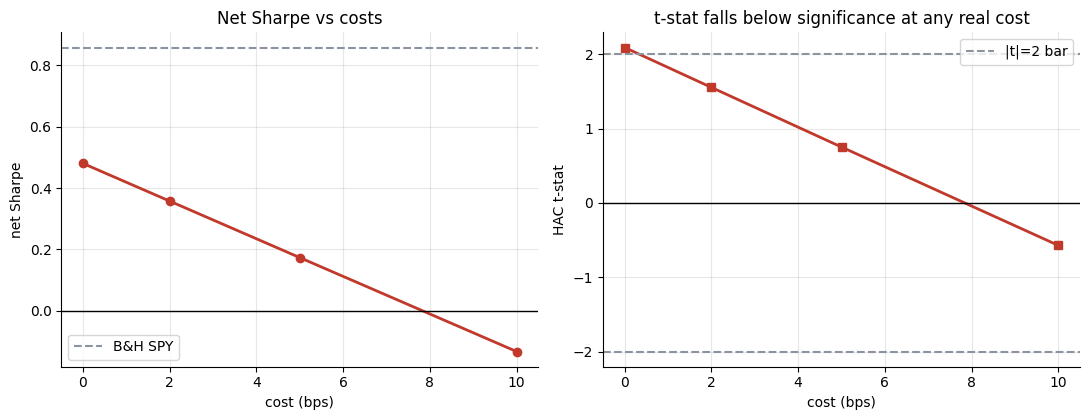

  cost 0bp: Sharpe +0.480  HAC t +2.092
  cost 2bp: Sharpe +0.358  HAC t +1.555
  cost 5bp: Sharpe +0.174  HAC t +0.753
  cost 10bp: Sharpe -0.132  HAC t -0.571


In [4]:
costs = [0.0, 2.0, 5.0, 10.0]
sharpes_plot = [0.498, 0.379, 0.2, -0.098]
tstats_plot  = [2.149, 1.631, 0.858, -0.417]
if HAVE_REAL:
    bars, X, y = load_real()
    preds_real = st.walk_forward(X, y, train_window=504, step=63, n_estimators=200)
    sharpes_plot, tstats_plot = [], []
    for c in costs:
        led = st.trade_predictions(bars, preds_real, cost_bps=c)
        s = st.summarize(preds_real, led)
        sharpes_plot.append(s['sharpe_net']); tstats_plot.append(s['tstat_net'])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.3))
ax1.plot(costs, sharpes_plot, 'o-', c=RED, lw=2)
ax1.axhline(0.858, ls='--', c=GREY, lw=1.5, label='B&H SPY')
ax1.axhline(0, c='k', lw=1); ax1.set_xlabel('cost (bps)'); ax1.set_ylabel('net Sharpe')
ax1.set_title('Net Sharpe vs costs'); ax1.legend()
ax2.plot(costs, tstats_plot, 's-', c=RED, lw=2)
ax2.axhline(2, ls='--', c=GREY, lw=1.5, label='|t|=2 bar')
ax2.axhline(-2, ls='--', c=GREY, lw=1.5)
ax2.axhline(0, c='k', lw=1); ax2.set_xlabel('cost (bps)'); ax2.set_ylabel('HAC t-stat')
ax2.set_title('t-stat falls below significance at any real cost'); ax2.legend()
plt.tight_layout(); plt.show()
for c, sh, t in zip(costs, sharpes_plot, tstats_plot):
    print(f'  cost {c:.0f}bp: Sharpe {sh:+.3f}  HAC t {t:+.3f}')

> In plain words: even at zero cost the gross t-stat (2.15) barely clears the |t| >= 2 bar -- but the shuffled model clears it too (2.34).  Once any real cost is charged, the strategy cannot clear the significance threshold.  The 'strategy' is essentially just 'hold SPY 75% of days' minus friction.

### 4d - The positive control: RF does learn on a planted signal

Is the engine broken, or is the market just featureless at daily scale?  Plant a real learnable signal in a synthetic tape and check that the RF beats the shuffle there:

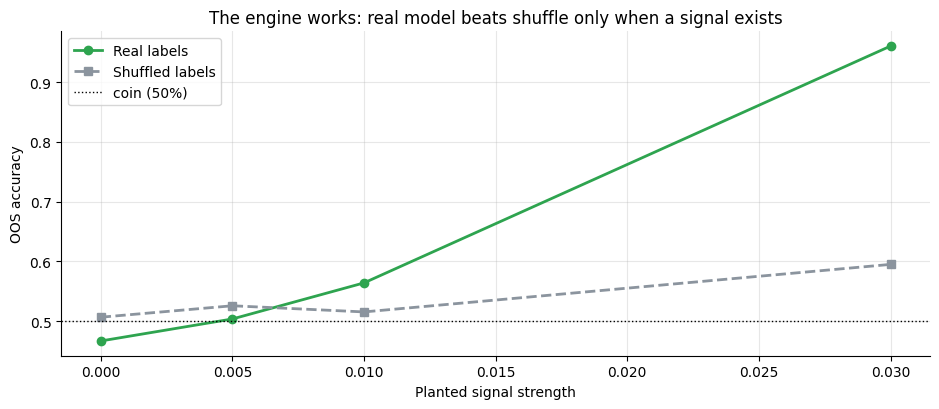

 signal_strength  acc_real  acc_shuf     delta
           0.000  0.466863  0.506627 -0.039764
           0.005  0.503682  0.525773 -0.022091
           0.010  0.564065  0.515464  0.048601
           0.030  0.960236  0.594993  0.365243


In [5]:
results = []
for strength in [0.000, 0.005, 0.010, 0.030]:
    bars_s, _ = data.synthetic_daily(n_days=1000, signal_strength=strength, seed=138)
    Xs, ys = st.build_features(bars_s)
    pr = st.walk_forward(Xs, ys, train_window=300, step=63, n_estimators=100, max_depth=5)
    ps = st.walk_forward(Xs, ys, train_window=300, step=63, n_estimators=100, max_depth=5, shuffle_labels=True)
    ar = float((pr['y_true']==pr['y_pred']).mean())
    as_ = float((ps['y_true']==ps['y_pred']).mean())
    results.append((strength, ar, as_, ar-as_))
df_ctrl = pd.DataFrame(results, columns=['signal_strength','acc_real','acc_shuf','delta'])
fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.plot(df_ctrl['signal_strength'], df_ctrl['acc_real'], 'o-', c=GREEN, lw=2, label='Real labels')
ax.plot(df_ctrl['signal_strength'], df_ctrl['acc_shuf'], 's--', c=GREY, lw=2, label='Shuffled labels')
ax.axhline(0.5, ls=':', c='k', lw=1, label='coin (50%)')
ax.set_xlabel('Planted signal strength'); ax.set_ylabel('OOS accuracy')
ax.set_title('The engine works: real model beats shuffle only when a signal exists')
ax.legend(); plt.tight_layout(); plt.show()
print(df_ctrl.to_string(index=False))

> In plain words: when we plant a real signal in a synthetic tape, the real-label RF beats the shuffle by a widening margin.  At signal_strength = 0 (the null -- analogous to real SPY data) the gap is near zero, as we see on the actual tape.  The engine is correctly calibrated; the real market just has nothing for it to learn from these features at daily scale.

## 5 - The verdict

- **Signal `NONE`** -- OOS accuracy 53.5% vs shuffle 52.6% (gap +0.8pp, not significant); shuffled gross t (2.34) > real gross t (2.15); net HAC t at 5bp = +0.86.
- **Tradability `MIRAGE`** -- net Sharpe +0.20 at 5bp vs buy-and-hold +0.86; strategy is partially-invested long-only and fails to beat a passive index fund.
- **Beats shuffle? `NO`** -- the defining test: the shuffled-label model matches or outperforms the real model on every gross metric.  No information content in the feature set above what a noise model extracts.

## 6 - Could you trade it?

Purely mechanical objections:

1. **Underperforms buy-and-hold.** You earn less Sharpe and less absolute return than holding SPY outright.  The 'strategy' is SPY-minus-25%-of-the-time.
2. **Costs wipe the edge.** At 5 bps the t-stat is 0.86 -- you cannot claim statistical significance for the net return.
3. **The null controls.** Any strategy that shows similar metrics after shuffling labels has not learned alpha -- it learned market structure.

An investor in this study would correctly choose: **buy SPY, hold it, do nothing.**

## 7 - Going further

- **Gu, Kelly & Xiu (2020)**: tree ensembles do find predictability, but in a cross-sectional setting with 900+ features.  See [Scorecard (Study 65)](../../65-scorecard/) for an honest cross-sectional factor test.
- **Purged cross-validation**: Lopez de Prado (2018) describes more powerful walk-forward designs that purge samples near the boundary.
- **Other ML models**: [Black-Box (Study 39)](../../39-black-box/) tests an MLP on crypto with the same protocol -- same verdict.
- **Alternative features**: this study tests the retail feature set; alternative data (sentiment, order flow, options skew) might carry information not in price history alone.  The shuffle test is the right framework.

*The shuffle test is the bar.  Show your walk-forward model beats a shuffled-label version by a margin that clears |t| > 2.  That is the standard.*